# Baja Data Analysis - IR_Sensor

There is only 1 channel as a way to measure the CVT temperature (CH0). The data will be measured each 0.1s.
Currently, the file will measure:
<ul>
    <li>Graph measuring voltage</li>
    <li>A dropdown/2 radio button to display temperature/2 graphs displaying in C, F</li>
    <li>Max, min temperature in C, F</li>
    <li>Max, min voltage </li>
<ul>

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import pandas as pd
import csv
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [35]:
# All the data type of float64
IR_df = pd.read_csv('data/Hat1_IR_Sensor_Acquisition1_09-10-2026.csv', dtype = {
    "elapsed_s" : "float64",
    "voltage_V" : "float64",
    "temp_C" : "float64",
    "temp_F" : "float64",
    "warning_C" : "float64",
    "warning_F" : "float64",
    "critical_C" : "float64",
    "critical_F" : "float64",
})
# Showing data
IR_df

slicing_corrupted = 4968

### CHECKING THE WARNING OR CRITICAL POINTS

In [36]:
slicing_corrupted = 4968
slicing_df = IR_df.iloc[0:slicing_corrupted]

warning_points = slicing_df[slicing_df['warning_C'] != 0] # only takes C
critical_points = slicing_df[slicing_df['critical_C'] != 0] # only takes C

warning_points

,elapsed_s,voltage_V,temp_C,temp_F,warning_C,warning_F,critical_C,critical_F


In [37]:
critical_points

,elapsed_s,voltage_V,temp_C,temp_F,warning_C,warning_F,critical_C,critical_F


#### -> Up to now, there are no period of time that the temperature reaches warning or critical limit

### VOLTAGE RANGE

In [38]:
print(f'Voltage range: [{slicing_df['voltage_V'].min()}, {slicing_df['voltage_V'].max()}]')
    

Voltage range: [1.018281, 1.175013]


### TEMPERATURE RANGE

In [39]:
print(f"Temperature range in C and F is: [{slicing_df['temp_C'].min()}, {slicing_df['temp_C'].max()}] and [{slicing_df['temp_F'].min()}, {slicing_df['temp_F'].max()}]")

Temperature range in C and F is: [48.5873, 68.1976] and [119.4571, 154.7556]


### GRAPH MEASURING VOLTAGE

### 1. MATPLOTLIB (FIXED)

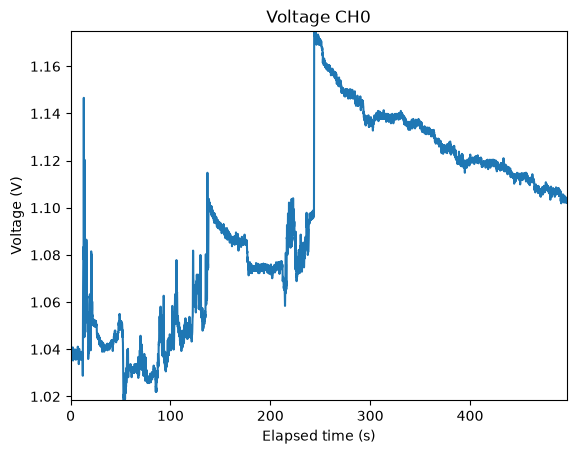

In [40]:

slicing_voltage = slicing_df['voltage_V']
slicing_time = slicing_df['elapsed_s']

plt.title('Voltage CH0')

plt.xlim(slicing_time.min(), slicing_time.max())
plt.ylim(slicing_voltage.min(), slicing_voltage.max())

plt.plot(slicing_time, slicing_voltage)

plt.xlabel('Elapsed time (s)')
plt.ylabel('Voltage (V)')   

plt.show() #hiding objects and memory

### PLOTLY (INTERACTIVE)

In [41]:
figure_1 = px.line(
    slicing_df,
    x = 'elapsed_s',
    y = 'voltage_V',
    title = 'Voltage CH0',
    labels = {
        'elapsed_s' : 'Elapsed time (s)',
        'voltage_V' : 'Voltage (V)'
    }
)

figure_1.show()

### TEMPERATURE GRAPH